In [1]:
import pandas as pd

df = pd.read_csv("merged.csv")
df.head()

C:\Users\sue\AppData\Local\Temp\ipykernel_35172\325935571.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [2]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [3]:
df[['StoreType', 'CompetitionOpenSinceMonth', 'SchoolHoliday', 'DayOfWeek']].head()

,StoreType,CompetitionOpenSinceMonth,SchoolHoliday,DayOfWeek
0,c,9.0,1,5
1,a,11.0,1,5
2,a,12.0,1,5
3,c,9.0,1,5
4,a,4.0,1,5


In [4]:
df[['StoreType', 'CompetitionOpenSinceMonth', 'SchoolHoliday', 'DayOfWeek']].isnull().sum()

StoreType                         0
CompetitionOpenSinceMonth    323348
SchoolHoliday                     0
DayOfWeek                         0
dtype: int64

In [5]:
print(df['StoreType'].value_counts())
print(df['CompetitionOpenSinceMonth'].value_counts().sort_index())
print(df['SchoolHoliday'].value_counts())
print(df['DayOfWeek'].value_counts().sort_index())

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64
CompetitionOpenSinceMonth
1.0      12452
2.0      37886
3.0      63548
4.0      87076
5.0      39608
6.0      45444
7.0      59434
8.0      36186
9.0     114254
10.0     55622
11.0     84455
12.0     57896
Name: count, dtype: int64
SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64
DayOfWeek
1    144730
2    145664
3    145665
4    145845
5    145845
6    144730
7    144730
Name: count, dtype: int64


In [6]:
df.groupby('StoreType')['Sales'].mean()

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64

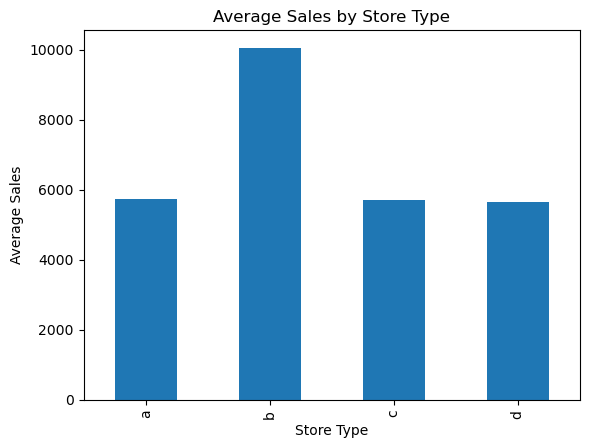

In [7]:
import matplotlib.pyplot as plt

df.groupby('StoreType')['Sales'].mean().plot(kind='bar')

plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.show()

Store type b has the highest average sales, while store types a, c and d have relatively similar and lower average sales. This suggests that store type may have an influence on sales.

In [8]:
month_sales = df.dropna(subset=['CompetitionOpenSinceMonth'])

month_sales.groupby('CompetitionOpenSinceMonth')['Sales'].mean()

CompetitionOpenSinceMonth
1.0     6172.995021
2.0     5429.783060
3.0     6018.509804
4.0     5721.389568
5.0     6253.914209
6.0     6355.309018
7.0     5605.731231
8.0     6242.269193
9.0     5674.837021
10.0    5672.669411
11.0    5482.371736
12.0    5620.760761
Name: Sales, dtype: float64

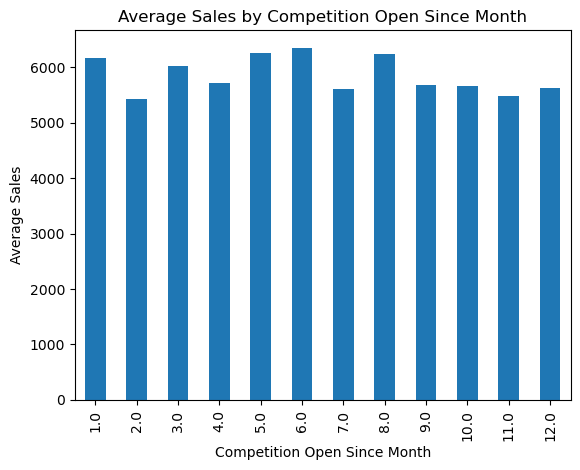

In [9]:
month_sales.groupby('CompetitionOpenSinceMonth')['Sales'].mean().plot(
    kind='bar'
)

plt.title('Average Sales by Competition Open Since Month')
plt.xlabel('Competition Open Since Month')
plt.ylabel('Average Sales')
plt.show()

Average sales vary slightly depending on the month when the competition opened. Stores with competition opening in months such as May, June and August show relatively higher average sales, while February and November are relatively lower. However, the differences are not very large, suggesting that competition opening month may have only a limited effect on sales.

In [12]:
df.groupby('SchoolHoliday')['Sales'].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

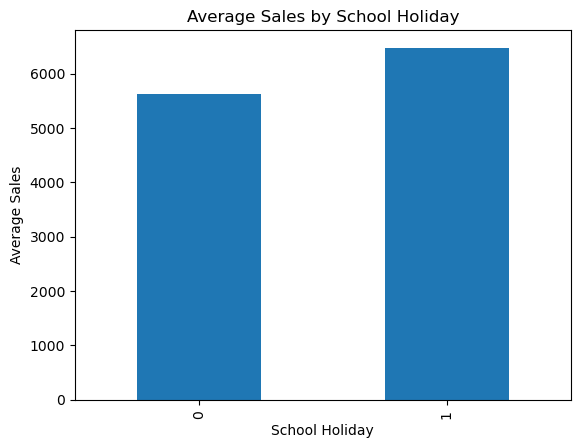

In [13]:
df.groupby('SchoolHoliday')['Sales'].mean().plot(kind='bar')

plt.title('Average Sales by School Holiday')
plt.xlabel('School Holiday')
plt.ylabel('Average Sales')
plt.show()

Average sales are higher during school holidays compared with non-school-holiday periods. This suggests that school holidays may have a positive effect on store sales.

In [14]:
df.groupby('DayOfWeek')['Sales'].mean()

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

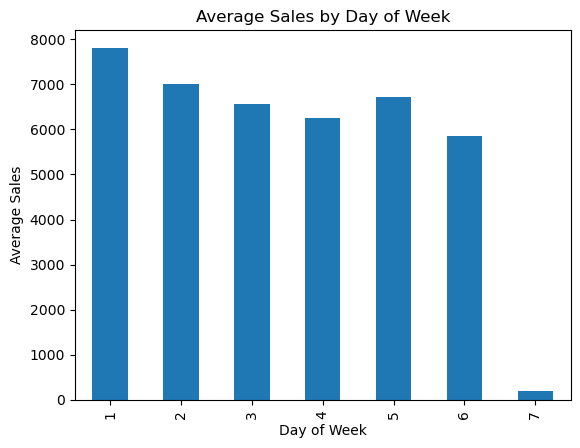

In [15]:
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar')

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()


Average sales vary noticeably across the week. Monday has the highest average sales, while Sunday has by far the lowest average sales. This suggests that day of week is an important feature for predicting sales.